# The Climate is Changing: How is the Research?

## Exploring Trends in Climate Articles: 2013 to 2023

#### This notebook explores SA concepts within the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

### Imports

In [38]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
sns.set_theme(style='white')
pio.renderers.default = 'iframe'

# Project-specific imports
import glob
from glob import glob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download
nltk_download('vader_lexicon')
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
# Scikit Learn
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF # Note importing of two topic modelers
        
# HTML
from IPython.display import display, HTML

# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")
# Same for csvs
sys.path.append(os.path.join(os.getcwd(), 'csvs'))
csvs_dir = "csvs"
csvs_files_paths = glob(f"{csvs_dir}/*.csv")
# And for resources
sys.path.append(os.path.join(os.getcwd(), 'resources'))
resources_dir = "resources"
resources_files_paths = glob(f"{resources_dir}/*.csv")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Defining OHCO, Emotions

In [2]:
OHCO = ['year', 'mth_day', 'doc_id', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    DOCS = OHCO[:3],
    MTH_DAY = OHCO[:2],
    YEAR = OHCO[:1]
)

bag = 'DOCS'

# Subset of columns from salex
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

### Get Syuzhet Lexicon, CORPUS

In [15]:
SALEX = pd.read_csv('resources/salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [16]:
LIB = pd.read_csv("csvs/LIB/LIB.csv").set_index('doc_id')
TOKENS = pd.read_csv('csvs/CORPUS/CORPUS.csv').set_index(OHCO)
#TOKENS = TOKENS.join(LIB)
TOKENS.head()

pos pos_group token_str  term_str
year mth_day doc_id sent_num token_num                                   
2018 12-18   0      0        0           DT        DT       The       the
                             1           JJ        JJ  southern  southern
                             2           NN        NN      cone      cone
                             3           IN        IN        of        of
                             4          NNP        NN     South     south

### Applying the Model

In [82]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left').fillna(0)
TOKENS_SA

pos pos_group token_str  term_str  \
year mth_day doc_id sent_num token_num                                      
2018 12-18   0      0        0           DT        DT       The       the   
                             1           JJ        JJ  southern  southern   
                             2           NN        NN      cone      cone   
                             3           IN        IN        of        of   
                             4          NNP        NN     South     south   
...                                     ...       ...       ...       ...   
2023 11-30   91     213      3          VBN        VB  streaked  streaked   
                             4           IN        IN        on        on   
                             5           DT        DT         a         a   
                             6           JJ        JJ    single    single   
                             7           NN        NN     plate     plate   

                                        anger  anticipation  disgust  fear  \
year mth_day doc_id sent_num token_num                                       
2018 12-18   0      0        0            0.0           0.0      0.0   0.0   
                             1            0.0           0.0      0.0   0.0   
                             2            0.0           0.0      0.0   0.0   
                             3            0.0           0.0      0.0   0.0   
                             4            0.0           0.0      0.0   0.0   
...                                       ...           ...      ...   ...   
2023 11-30   91     213      3            0.0           0.0      0.0   0.0   
                             4            0.0           0.0      0.0   0.0   
                             5            0.0           0.0      0.0   0.0   
                             6            0.0           0.0      0.0   0.0   
                             7            0.0           0.0      0.0   0.0   

                                        joy  negative  positive  sadness  \
year mth_day doc_id sent_num token_num                                     
2018 12-18   0      0        0          0.0       0.0       0.0      0.0   
                             1          0.0       0.0       0.0      0.0   
                             2          0.0       0.0       0.0      0.0   
                             3          0.0       0.0       0.0      0.0   
                             4          0.0       0.0       0.0      0.0   
...                                     ...       ...       ...      ...   
2023 11-30   91     213      3          0.0       0.0       0.0      0.0   
                             4          0.0       0.0       0.0      0.0   
                             5          0.0       0.0       0.0      0.0   
                             6          0.0       0.0       0.0      0.0   
                             7          0.0       0.0       0.0      0.0   

                                        surprise  trust  sentiment  
year mth_day doc_id sent_num token_num                              
2018 12-18   0      0        0               0.0    0.0        0.0  
                             1               0.0    0.0        0.0  
                             2               0.0    0.0        0.0  
                             3               0.0    0.0        0.0  
                             4               0.0    0.0        0.0  
...                                          ...    ...        ...  
2023 11-30   91     213      3               0.0    0.0        0.0  
                             4               0.0    0.0        0.0  
                             5               0.0    0.0        0.0  
                             6               0.0    0.0        0.0  
                             7               0.0    0.0        0.0  

[513675 rows x 15 columns]

### Comparing Years

In [46]:
YR_SA = TOKENS_SA.groupby(TOKENS_SA.index.get_level_values('year'))[emo_cols].mean()
YR_SA

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
year,,,,,,,,,
2013,0.004727,0.008645,0.005751,0.007978,0.008109,0.008133,0.004834,0.015813,0.002191
2018,0.005980,0.008340,0.008037,0.010731,0.008978,0.009444,0.004861,0.017282,-0.000068
2023,0.006015,0.009955,0.006459,0.009352,0.009209,0.008178,0.004120,0.018770,0.006577


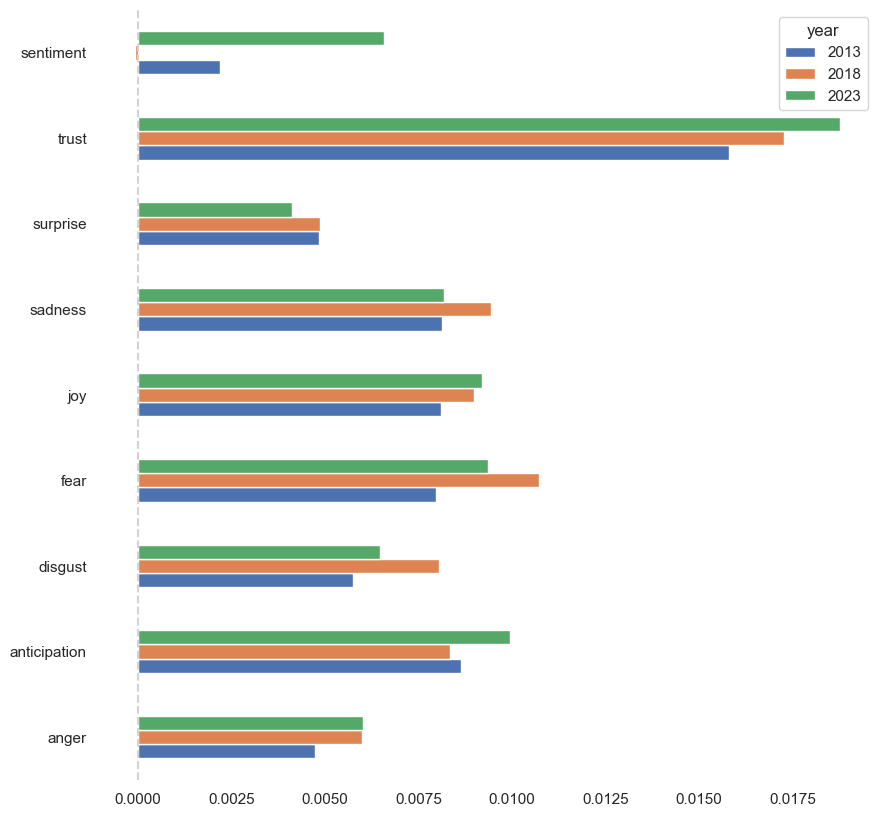

In [47]:
ax = YR_SA.loc[[2013, 2018, 2023]].T.plot.barh(figsize=(10,10))
ax.axvline(0, c='lightgray', ls='--')
sns.despine(left=True, bottom=True)
plt.show()

### Exploring Sentiment Further

In [22]:
def tag_term_str(x):
    if pd.isna(x.sentiment):
        html_str = x.term_str
    else:
        html_str = f"<span class='sent{int(np.sign(x.sentiment))}'>{x.term_str}</span>"
    return html_str

TOKENS_SA['html'] = TOKENS_SA.apply(tag_term_str, axis=1)

In [57]:
# Join tagged and untagged tokens into sentences for display
# Define a variable for sentence index
sent_i= TOKENS_SA.index.get_level_values('sent_num')
SENT_SA = TOKENS_SA.groupby(sent_i)[emo_cols].mean()
SENT_SA['html_str'] = TOKENS_SA.groupby(sent_i)[['html']].apply(lambda x: ' '.join(map(str, x.html)))

SENT_SA.sample(10).html_str.tolist()

["<span class='sent0'>furthermore</span> <span class='sent0'>blockchain</span> <span class='sent0'>is</span> <span class='sent0'>being</span> <span class='sent0'>explored</span> <span class='sent0'>for</span> <span class='sent0'>its</span> <span class='sent0'>ability</span> <span class='sent0'>to</span> <span class='sent0'>automate</span> <span class='sent0'>financial</span> <span class='sent0'>contracts</span> <span class='sent0'>and</span> <span class='sent0'>support</span> <span class='sent0'>corporate</span> <span class='sent0'>finance</span> <span class='sent0'>among</span> <span class='sent0'>other</span> <span class='sent0'>applications</span> <span class='sent0'>this</span> <span class='sent0'>file</span> <span class='sent0'>is</span> <span class='sent0'>an</span> <span class='sent0'>r</span> <span class='sent0'>list</span> <span class='sent0'>where</span> <span class='sent0'>each</span> <span class='sent0'>list</span> <span class='sent0'>element</span> <span class='sent0'>is</

In [75]:
# This function will print sentences using color coding for sentiment values
def sample_sentences(df, n=10):
    
    rows = []
    for idx in df.sample(n).index:

        # Map background color to sentiment valences
        valence = round(df.loc[idx, 'sentiment'], 4)     
        if valence > 0: color = '#ccffcc'
        elif valence < 0: color = '#ffcccc'
        else: color = '#f2f2f2'

        # Create a table row
        rows.append(f"""
        <tr style="background-color:{color};padding:.5rem 1rem;font-size:80%;">
            <td>{idx}</td>
            <td width="800" style="text-align:left;">{df.loc[idx, 'html_str']}</td>
            <td>{valence}</td>
        </tr>
        """)

    # Define CSS style element to apply color to fonts by class
    display(HTML("""
    <style>
    #sample1 td{
        font-size:80%;
        vertical-align:top;
    } 
    .sent-1{
        color:red;
        font-weight:bold;
    } 
    .sent1{
        color:green;
        font-weight:bold;
    }
    </style>
    """))
    
    # Create the table
    display(HTML(f"""
    <table id="sample1">
        <tr>
            <th>ID</th>
            <th>Sentence</th>
            <th width="600">Valence</th>
        </tr>
        {"".join(rows)}
    </table>
    """))

In [78]:
sample_sentences(SENT_SA)

Some interesting findings reside in these sample tables. Of particular interest are the classification of mosquito, black, endemic, soil, and unpublished as negative words. Mosquitos are, of course, annoying to humans, but do play a crucial role in ecosystems; scientists generally believe no species has a positive or negative connation, though in literature, mosquitos may stand for irritating in a metaphor, and they do carry disease that can transmit to humans. Black is a tricky one: throughout literature, one can find references to black as a stand-in for darkness and sadness ('a black mood') but does this stem from racist motivations? (See Heathcliff's terrifying 'black' face described throughout Wuthering Heights as a demon or devil.) In the sentences I saw, black simply described the color of a fin - quite neutral. Soil can mean 'to dirty', so it gets negative sentiment, but as a noun referring to dirt, it is actually quite beneficial, or at the very least neutral! Finally, endemic means native of or to, which is in and of itself a neutral meaning. However, it can often refer to disease and I assume that is why it got classified as negative. Finally, a cheeky note that unpublished can stand in as a nod to the oft-stated "publish or perish" dilemma many scientists face. 

### Creating VOCAB_SENT, BOW_SENT, DOC_SENT

In [92]:
VOCAB = pd.read_csv("csvs/VOCAB/VOCAB_DOCS_final.csv")
VOCAB_SENT = VOCAB.join(SALEX, on='term_str', how='left').fillna(0)
VOCAB_SENT.to_csv("csvs/VOCAB/VOCAB_SENT.csv")
VOCAB_SENT.to_csv("csvs/VOCAB/VOCAB_final.csv") # Most comprehensive VOCAB table
VOCAB_SENT.head()

,term_str,year,n,p,i,p_yr,i_yr,n_pos_group,cat_pos_group,n_pos,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
0,the,2013,4963,0.009662,6.693500,0.059097,4.080779,2,"{'VB', 'DT'}",2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,of,2013,3106,0.006047,7.369654,0.036985,4.756933,3,"{'CC', 'NN', 'IN'}",3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,and,2013,2631,0.005122,7.609101,0.031329,4.996380,2,"{'CC', 'NN'}",2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,in,2013,2310,0.004497,7.796819,0.027506,5.184098,2,"{'NN', 'IN'}",2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,to,2013,1710,0.003329,8.230716,0.020362,5.617995,2,"{'TO', 'NN'}",2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [101]:
BOW = pd.read_csv("csvs/TFIDF/BOW_YEAR.csv")
BOW_SENT = BOW.join(SALEX, on='term_str', how='left').fillna(0)
BOW_SENT.to_csv("csvs/VOCAB/VOCAB_SENT.csv")
BOW_SENT.sample(n=5)

,year,term_str,n,df,idf,tfidf_mean,tfidf_mean_L2,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
26217,2023,authenticity,10,1,2.000000,1.000229,0.006774,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
26596,2023,biparentallyinherited,2,1,2.000000,1.000046,0.006773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11942,2018,certified,1,2,1.415037,0.707586,0.004792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12475,2018,concepción,1,1,2.000000,1.000029,0.006773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
985,2013,alone,6,3,1.000000,0.500538,0.003390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Compute sentiment per DOC